**1. Preparación y organización de los datos**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

autos = pd.read_csv("dataset/auto-mpg.csv")
autos.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [2]:
autos["horsepower"] = autos["horsepower"].replace("?", pd.NA)
autos["horsepower"] = pd.to_numeric(autos["horsepower"])
autos["horsepower"] = autos["horsepower"].fillna(autos["horsepower"].median())

**2. Exploración de los datos**

In [3]:
autos[["mpg", "displacement", "horsepower", "weight"]].describe()

,mpg,displacement,horsepower,weight
count,398.000000,398.000000,398.000000,398.000000
mean,23.514573,193.425879,104.304020,2970.424623
std,7.815984,104.269838,38.222625,846.841774
min,9.000000,68.000000,46.000000,1613.000000
25%,17.500000,104.250000,76.000000,2223.750000
50%,23.000000,148.500000,93.500000,2803.500000
75%,29.000000,262.000000,125.000000,3608.000000
max,46.600000,455.000000,230.000000,5140.000000


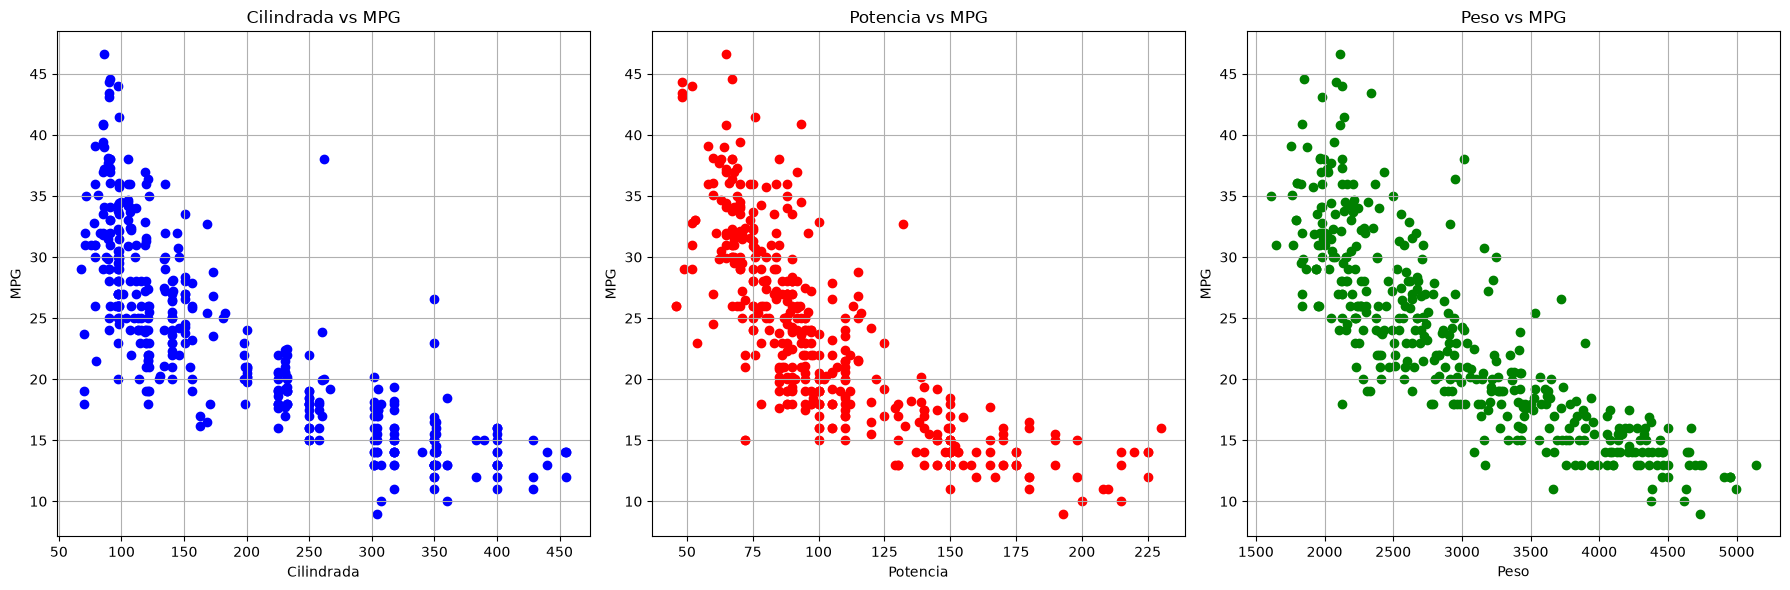

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(autos["displacement"], autos["mpg"], color="blue")
axes[0].set_xlabel("Cilindrada")
axes[0].set_ylabel("MPG")
axes[0].set_title("Cilindrada vs MPG")
axes[0].grid()

axes[1].scatter(autos["horsepower"], autos["mpg"], color="red")
axes[1].set_xlabel("Potencia")
axes[1].set_ylabel("MPG")
axes[1].set_title("Potencia vs MPG")
axes[1].grid()

axes[2].scatter(autos["weight"], autos["mpg"], color="green")
axes[2].set_xlabel("Peso")
axes[2].set_ylabel("MPG")
axes[2].set_title("Peso vs MPG")
axes[2].grid()

plt.tight_layout()
plt.show()

**3. Modelado de los datos**

In [5]:
X = autos[["displacement", "horsepower", "weight"]]
y = autos["mpg"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Intercepto:", modelo.intercept_)
print("Coeficientes:", modelo.coef_)

Intercepto: 45.210434712596324
Coeficientes: [-0.00841829 -0.03992023 -0.00534513]


In [7]:
y_pred = modelo.predict(X_test)

**4. Evaluación del modelo**

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
varianza = explained_variance_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)
print("Varianza explicada:", varianza)

MAE: 3.1257760481870265
MSE: 14.77066202183622
R²: 0.7252810304784902
Varianza explicada: 0.7256022199997663


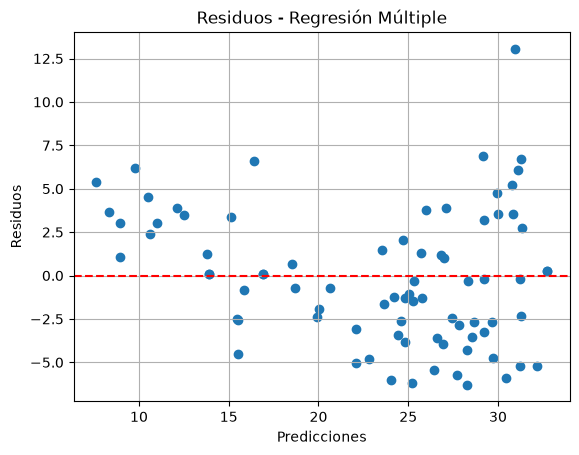

In [9]:
residuos = y_test - y_pred

plt.scatter(y_pred, residuos)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Múltiple")
plt.grid()
plt.show()